# Q4 - Repeat vs. Non-repeat Applicants: Supply side focused

**Author:** Belinda (Gia Bao) Ngo

**Datasets:** `40B_zip_long_lat.csv` (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)

**Instruction**: Download the CSV file above and move them to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "../data/40B_zip_long_lat.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
print(len(df))
df.head()

1609


,id_number,submission_date,age,disability,chapa_races,census_races,current_residence_town_city,current_residence_state,current_residence_zip,application_source,...,race_white,property_lat,property_lon,current_lat,current_lon,distance_mi,current_county,property_county,local_applicant_county,local_applicant_town
0,150733,2022-02-08,65,0,White/Non-Minority,White alone,Somerville,MA,2145,Unknown,...,1,42.70,-71.11,42.39,-71.10,21.403626,Middlesex,Essex,0.0,0.0
1,439181,2022-02-08,59,0,Hispanic/Latino,Unknown,Westford,MA,1886,Unknown,...,0,42.70,-71.11,42.58,-71.43,18.290818,Middlesex,Essex,0.0,0.0
2,226436,2022-02-08,60,0,White/Non-Minority,White alone,Nashua,NH,3060,Unknown,...,1,42.70,-71.11,42.74,-71.45,17.523738,NaN,Essex,0.0,0.0
3,170029,2021-06-15,35,0,White/Non-Minority,White alone,Waltham,MA,2453,Unknown,...,1,42.48,-71.26,42.37,-71.24,7.661090,Middlesex,Middlesex,1.0,0.0
4,569863,2021-06-15,38,0,Black or African American,Black or African American alone,Woburn,MA,1801,Unknown,...,0,42.48,-71.26,42.48,-71.15,5.620161,Norfolk,Middlesex,0.0,0.0


## Visualizations

### Are some Marketing Sources attracting Repeat vs Non-repeat Applicants?

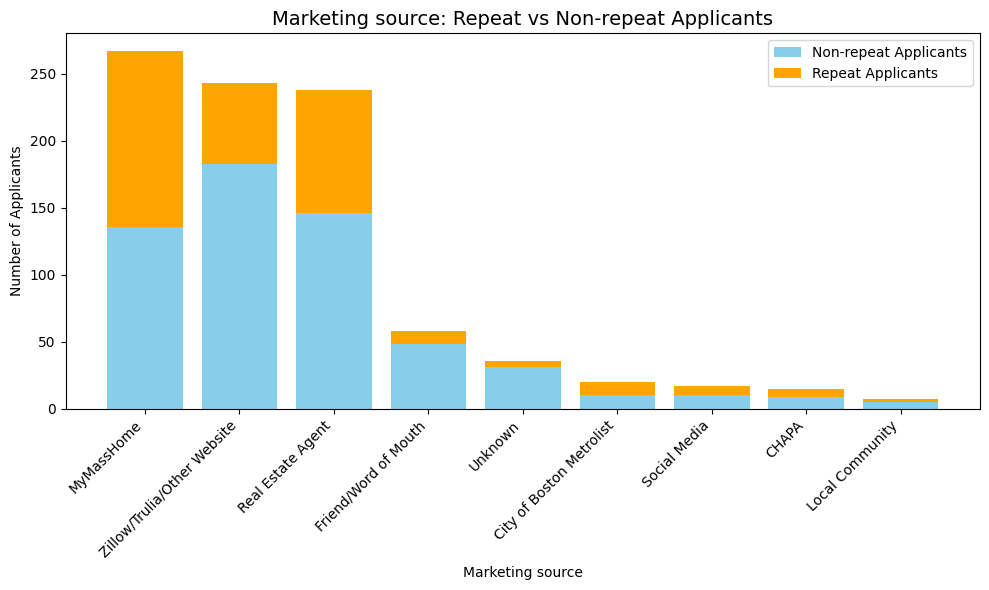

In [ ]:
# total applications per town (count all rows)
all_applications = df.groupby('application_source')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('application_source')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).head(30).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(10,6))
plt.bar(top_30_towns, non_repeat_applications, color='skyblue', label='Non-repeat Applicants')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='orange', label='Repeat Applicants')

plt.title("Marketing source: Repeat vs Non-repeat Applicants", fontsize=14)
plt.ylabel("Number of Applicants")
plt.xlabel("Marketing source")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

### Property Towns: Repeat vs Non-repeat Applicants

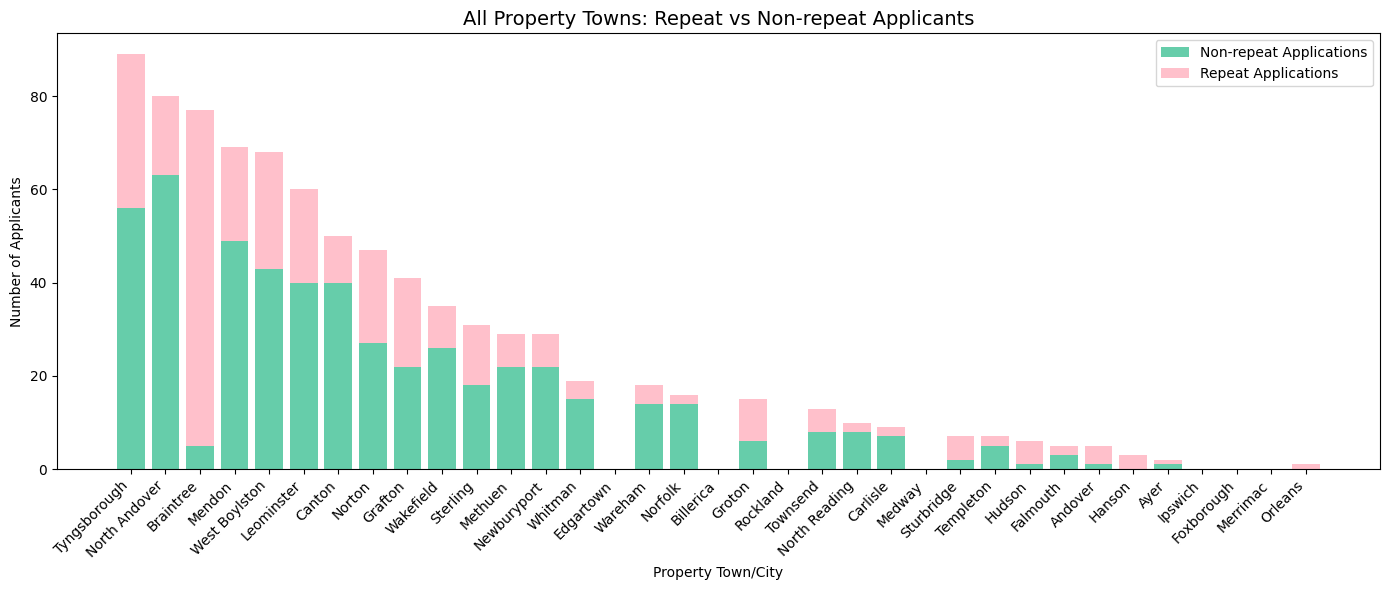

In [ ]:
# total applications per town (count all rows)
all_applications = df.groupby('property_town_city')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('property_town_city')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(14,6))
plt.bar(top_30_towns, non_repeat_applications, color='mediumaquamarine', label='Non-repeat Applications')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='pink', label='Repeat Applications')

plt.title("All Property Towns: Repeat vs Non-repeat Applicants", fontsize=14)
plt.ylabel("Number of Applicants")
plt.xlabel("Property Town/City")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

### Which Town/City has the most Property listings?

In [ ]:
col = "property_town_city"
df[col].nunique(), df[col].isnull().sum()

(35, np.int64(0))

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/449336351.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


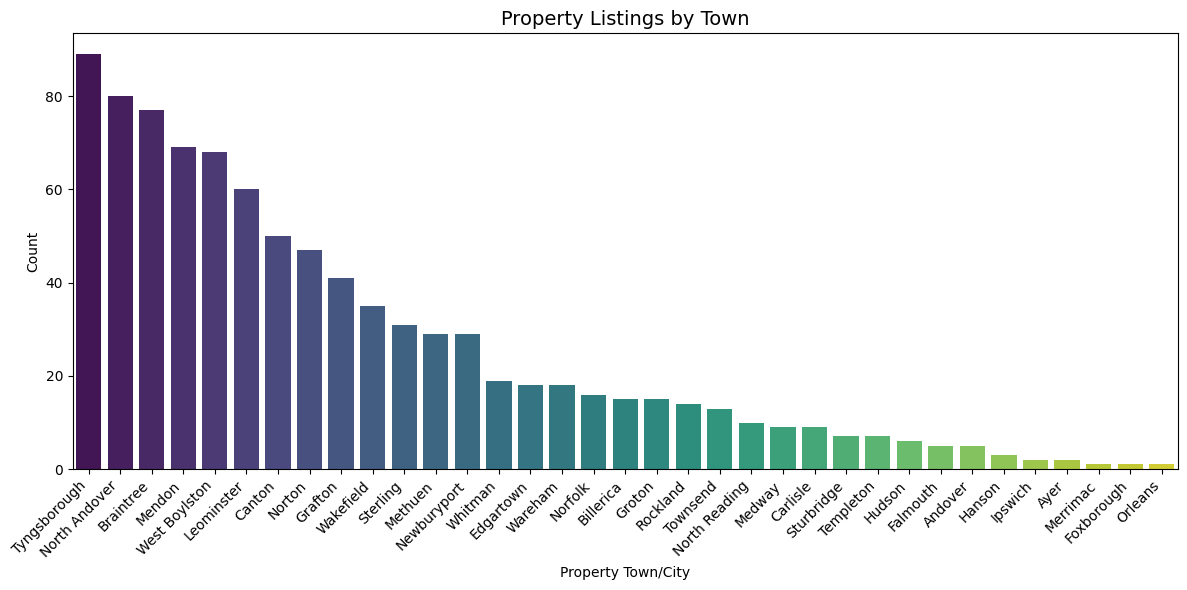

In [ ]:
plt.figure(figsize=(12,6))

top_towns = df['property_town_city'].value_counts().index[:]

# Filter and define order
sns.countplot(
    data=df[df['property_town_city'].isin(top_towns)],
    x='property_town_city',
    order=top_towns,
    palette='viridis'
)

plt.title("Property Listings by Town", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Property Town/City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()